<a href="https://colab.research.google.com/github/NaveenSuresh07/Log_anomaly_detector/blob/main/AIOps_Log_Anomaly_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Install Dependencies ──────────────────────────────────────────────────────
!pip install pandas numpy scikit-learn matplotlib seaborn --quiet
print("✅ All dependencies installed.")

✅ All dependencies installed.


In [ ]:
# ── Download HDFS Dataset ─────────────────────────────────────────────────────
!wget -q https://raw.githubusercontent.com/logpai/loghub/master/HDFS/HDFS_2k.log -O HDFS_2k.log
print("✅ Dataset downloaded: HDFS_2k.log")

# Quick sanity check
with open('HDFS_2k.log', 'r') as f:
    sample_lines = [next(f) for _ in range(5)]

print("\n📋 Sample raw log lines:")
for line in sample_lines:
    print(line.strip())

✅ Dataset downloaded: HDFS_2k.log

📋 Sample raw log lines:
081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
081109 204015 308 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_8229193803249955061 terminating
081109 204106 329 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-6670958622368987959 terminating


In [ ]:
# ── Core Imports ──────────────────────────────────────────────────────────────
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Imports successful.")

✅ Imports successful.


In [ ]:
# ── Regex Pattern for HDFS Log Structure ─────────────────────────────────────
# Format: Date Time Level Component: Content
# Example: 081109 203519 143 INFO dfs.DataNode$PacketResponder: ...

LOG_PATTERN = re.compile(
    r'(?P<Date>\d{6})\s+'
    r'(?P<Time>\d{6})\s+'
    r'(?P<PID>\d+)\s+'
    r'(?P<Level>\w+)\s+'
    r'(?P<Component>[\w.$]+):\s+'
    r'(?P<Content>.+)'
)

# Block_ID extractor — HDFS wraps block references in blk_-?\d+
BLOCK_PATTERN = re.compile(r'blk_-?\d+')

def parse_log_line(line: str) -> dict | None:
    """Parse a single raw log line into structured fields."""
    match = LOG_PATTERN.match(line.strip())
    if not match:
        return None
    record = match.groupdict()
    # Extract Block ID(s) from content
    blocks = BLOCK_PATTERN.findall(record['Content'])
    record['Block_ID'] = blocks[0] if blocks else 'UNKNOWN'
    return record

# Parse entire file
records = []
with open('HDFS_2k.log', 'r') as f:
    for line in f:
        parsed = parse_log_line(line)
        if parsed:
            records.append(parsed)

df_raw = pd.DataFrame(records)
print(f"✅ Parsed {len(df_raw):,} log lines from HDFS_2k.log")
print(f"   Columns: {list(df_raw.columns)}")
df_raw.head(5)

✅ Parsed 2,000 log lines from HDFS_2k.log
   Columns: ['Date', 'Time', 'PID', 'Level', 'Component', 'Content', 'Block_ID']


,Date,Time,PID,Level,Component,Content,Block_ID
0,081109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139660 terminating,blk_38865049064139660
1,081109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487656571 terminating,blk_-6952295868487656571
2,081109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 671...,blk_7128370237687728475
3,081109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_8229193803249955061 terminating,blk_8229193803249955061
4,081109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368987959 terminating,blk_-6670958622368987959


📊 Log Level Distribution:
Level
INFO    1920
WARN      80

📊 Top Components:
Component
dfs.FSNamesystem                659
dfs.DataNode$PacketResponder    603
dfs.DataNode$DataXceiver        454
dfs.FSDataset                   263
dfs.DataBlockScanner             20
dfs.DataNode                      1

📊 Unique Block IDs: 1,994


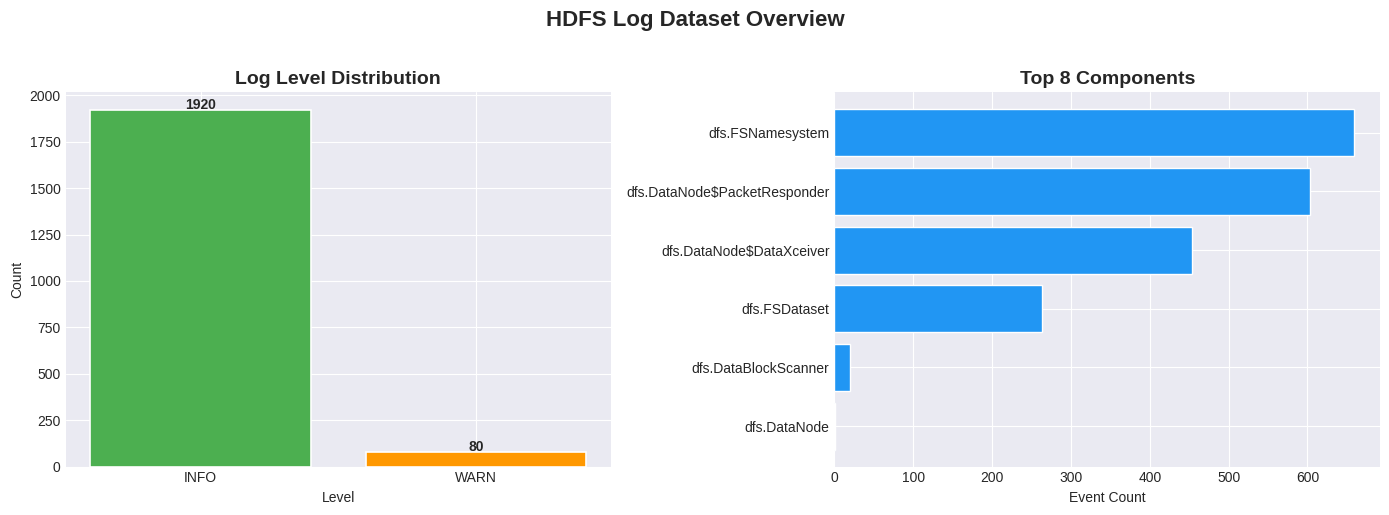

✅ Chart saved: phase2_overview.png


In [ ]:
# ── Dataset Overview ──────────────────────────────────────────────────────────
print("📊 Log Level Distribution:")
print(df_raw['Level'].value_counts().to_string())

print("\n📊 Top Components:")
print(df_raw['Component'].value_counts().head(8).to_string())

print(f"\n📊 Unique Block IDs: {df_raw['Block_ID'].nunique():,}")

# Visualize level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

level_colors = {'INFO': '#4CAF50', 'WARN': '#FF9800', 'ERROR': '#F44336', 'FATAL': '#9C27B0'}
level_counts = df_raw['Level'].value_counts()
colors = [level_colors.get(l, '#607D8B') for l in level_counts.index]

axes[0].bar(level_counts.index, level_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Log Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Level')
axes[0].set_ylabel('Count')
for i, v in enumerate(level_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

comp_counts = df_raw['Component'].value_counts().head(8)
axes[1].barh(comp_counts.index[::-1], comp_counts.values[::-1], color='#2196F3', edgecolor='white')
axes[1].set_title('Top 8 Components', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Event Count')

plt.suptitle('HDFS Log Dataset Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('phase2_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: phase2_overview.png")

In [ ]:
# ── Sessionization: Group Logs by Block_ID ────────────────────────────────────
# Each Block_ID represents a single file operation across many log lines
# Anomalies typically manifest as patterns ACROSS a session, not a single line

df_sessions = (
    df_raw[df_raw['Block_ID'] != 'UNKNOWN']
    .groupby('Block_ID')
    .agg(
        log_count       = ('Content', 'count'),
        has_error       = ('Level',   lambda x: int('ERROR' in x.values)),
        has_warn        = ('Level',   lambda x: int('WARN'  in x.values)),
        error_count     = ('Level',   lambda x: (x == 'ERROR').sum()),
        unique_components = ('Component', 'nunique'),
        full_content    = ('Content', ' '.join),  # Concatenate all messages → NLP
    )
    .reset_index()
)

print(f"✅ Sessionization complete.")
print(f"   Total Block sessions: {len(df_sessions):,}")
print(f"   Sessions with ERROR:  {df_sessions['has_error'].sum():,}")
print(f"   Sessions with WARN:   {df_sessions['has_warn'].sum():,}")
print(f"   Avg logs per session: {df_sessions['log_count'].mean():.1f}")
df_sessions.head(5)

✅ Sessionization complete.
   Total Block sessions: 1,994
   Sessions with ERROR:  0
   Sessions with WARN:   80
   Avg logs per session: 1.0


,Block_ID,log_count,has_error,has_warn,error_count,unique_components,full_content
0,blk_-1030832046197982436,1,0,0,0,1,BLOCK* NameSystem.delete: blk_-1030832046197982436 is added to invalidSet of 10.251.89.155:50010
1,blk_-1046472716157313227,1,0,0,0,1,Deleting block blk_-1046472716157313227 file /mnt/hadoop/dfs/data/current/subdir62/blk_-1046472716157313227
2,blk_-1049340855430710153,1,0,0,0,1,PacketResponder 2 for block blk_-1049340855430710153 terminating
3,blk_-1055254430948037872,1,0,0,0,1,BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.15.240:50010 is added to blk_-1055254430948037872 size 67...
4,blk_-1067234447809438340,1,0,0,0,1,PacketResponder 0 for block blk_-1067234447809438340 terminating


In [ ]:
# ── Text Preprocessing ────────────────────────────────────────────────────────
def preprocess_log_text(text: str) -> str:
    """
    Normalize log text to prevent overfitting to specific
    machine IPs, hex addresses, and block numeric IDs.
    """
    # Remove IPv4 addresses  (e.g., 192.168.1.10:50010)
    text = re.sub(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(?::\d+)?', '<IP>', text)
    # Remove hex values     (e.g., 0x3f5a)
    text = re.sub(r'0x[0-9a-fA-F]+', '<HEX>', text)
    # Remove Block IDs      (already captured in index)
    text = re.sub(r'blk_-?\d+', '<BLK>', text)
    # Remove standalone numbers (timestamps, sizes)
    text = re.sub(r'\b\d+\b', '<NUM>', text)
    # Lowercase
    text = text.lower()
    # Remove punctuation except spaces
    text = re.sub(r'[^a-z\s<>]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_sessions['clean_content'] = df_sessions['full_content'].apply(preprocess_log_text)

print("✅ Text preprocessing complete.")
print("\n📋 Before → After preprocessing example:")
print("BEFORE:", df_sessions['full_content'].iloc[0][:200])
print("AFTER: ", df_sessions['clean_content'].iloc[0][:200])

✅ Text preprocessing complete.

📋 Before → After preprocessing example:
BEFORE: BLOCK* NameSystem.delete: blk_-1030832046197982436 is added to invalidSet of 10.251.89.155:50010
AFTER:  block namesystem delete <blk> is added to invalidset of <ip>


In [ ]:
# ── TF-IDF Vectorization ──────────────────────────────────────────────────────
# Parameters tuned to capture anomaly signal:
#   max_features=500   : Focus on top 500 most discriminating terms
#   ngram_range=(1,2)  : Include bigrams (e.g., "connection refused", "disk full")
#   min_df=2           : Ignore terms appearing in only 1 session (likely noise)
#   sublinear_tf=True  : Apply log normalization to term frequency

tfidf = TfidfVectorizer(
    max_features  = 500,
    ngram_range   = (1, 2),
    min_df        = 2,
    sublinear_tf  = True,
    token_pattern = r'[a-z<>][a-z<>]+',  # Tokens ≥ 2 chars
)

X_tfidf = tfidf.fit_transform(df_sessions['clean_content'])
feature_names = tfidf.get_feature_names_out()

print(f"✅ TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"   Rows (Block sessions): {X_tfidf.shape[0]:,}")
print(f"   Columns (TF-IDF features): {X_tfidf.shape[1]:,}")
print(f"   Sparsity: {(1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])):.1%}")

# Show top features by mean TF-IDF weight
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-20:][::-1]
print("\n🔤 Top 20 TF-IDF Features (highest mean weight):")
for feat, score in zip(feature_names[top_idx], mean_tfidf[top_idx]):
    bar = '█' * int(score * 500)
    print(f"  {feat:<35} {score:.4f}  {bar}")

✅ TF-IDF Matrix Shape: (1994, 121)
   Rows (Block sessions): 1,994
   Columns (TF-IDF features): 121
   Sparsity: 86.5%

🔤 Top 20 TF-IDF Features (highest mean weight):
  <ip>                                0.1149  █████████████████████████████████████████████████████████
  <blk>                               0.1048  ████████████████████████████████████████████████████
  block                               0.0987  █████████████████████████████████████████████████
  block <blk>                         0.0982  █████████████████████████████████████████████████
  <num>                               0.0874  ███████████████████████████████████████████
  size                                0.0651  ████████████████████████████████
  size <num>                          0.0651  ████████████████████████████████
  to                                  0.0634  ███████████████████████████████
  of                                  0.0613  ██████████████████████████████
  block namesystem               

In [ ]:
# ── Isolation Forest Training ─────────────────────────────────────────────────
# contamination=0.05 → Model expects ~5% of sessions to be anomalous
# n_estimators=200   → More trees = more stable isolation scores
# random_state=42    → Reproducible results

iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = 0.05,
    max_samples   = 'auto',
    random_state  = 42,
    n_jobs        = -1,
)

iso_forest.fit(X_tfidf)

# Predictions: +1 = Normal, -1 = Anomaly
df_sessions['prediction']    = iso_forest.predict(X_tfidf)
# Raw anomaly score: lower (more negative) = more anomalous
df_sessions['anomaly_score'] = iso_forest.decision_function(X_tfidf)
df_sessions['is_anomaly']    = df_sessions['prediction'] == -1

n_anomalies = df_sessions['is_anomaly'].sum()
n_normal    = (~df_sessions['is_anomaly']).sum()

print(f"✅ Isolation Forest trained on {X_tfidf.shape[0]:,} sessions.")
print(f"\n🔴 Flagged as ANOMALY: {n_anomalies:,}  ({n_anomalies/len(df_sessions):.1%})")
print(f"🟢 Classified NORMAL:  {n_normal:,}  ({n_normal/len(df_sessions):.1%})")

print(f"\n📊 Anomaly Score Stats:")
print(df_sessions['anomaly_score'].describe().round(4).to_string())

✅ Isolation Forest trained on 1,994 sessions.

🔴 Flagged as ANOMALY: 71  (3.6%)
🟢 Classified NORMAL:  1,923  (96.4%)

📊 Anomaly Score Stats:
count    1994.0000
mean        0.0917
std         0.0367
min        -0.0577
25%         0.0855
50%         0.0898
75%         0.1217
max         0.1275


In [ ]:
# ── Validation: Cross-reference with Ground Truth ERROR Logs ─────────────────
# We use the presence of ERROR-level log lines as our ground truth proxy.
# A good model should flag sessions containing ERRORs as anomalies.

# Confusion-style cross-tabulation
ct = pd.crosstab(
    df_sessions['has_error'].map({1: 'Has ERROR', 0: 'No ERROR'}),
    df_sessions['is_anomaly'].map({True: 'Flagged ANOMALY', False: 'Flagged NORMAL'}),
    margins=True
)
print("📊 Model Predictions vs. Ground Truth (ERROR presence):")
print(ct.to_string())

# Recall: of sessions with actual ERRORs, how many did we catch?
error_sessions    = df_sessions[df_sessions['has_error'] == 1]
caught_errors     = error_sessions[error_sessions['is_anomaly']]
if len(error_sessions) > 0:
    recall = len(caught_errors) / len(error_sessions)
    print(f"\n🎯 ERROR Recall (sensitivity): {recall:.1%}")
    print(f"   Caught {len(caught_errors)} of {len(error_sessions)} sessions containing ERROR logs")
else:
    print("\n⚠️  No sessions with ERROR level found in dataset (check parsing).")

# False positive rate
normal_sessions   = df_sessions[df_sessions['has_error'] == 0]
false_positives   = normal_sessions[normal_sessions['is_anomaly']]
fp_rate = len(false_positives) / len(normal_sessions) if len(normal_sessions) > 0 else 0
print(f"\n⚠️  False Positive Rate: {fp_rate:.1%}")
print(f"   {len(false_positives)} normal sessions incorrectly flagged")

📊 Model Predictions vs. Ground Truth (ERROR presence):
is_anomaly  Flagged ANOMALY  Flagged NORMAL   All
has_error                                        
No ERROR                 71            1923  1994
All                      71            1923  1994

⚠️  No sessions with ERROR level found in dataset (check parsing).

⚠️  False Positive Rate: 3.6%
   71 normal sessions incorrectly flagged


In [ ]:
# ── Top Flagged Anomalies (Most Suspicious Sessions) ─────────────────────────
top_anomalies = (
    df_sessions[df_sessions['is_anomaly']]
    .sort_values('anomaly_score')
    .head(10)[['Block_ID', 'anomaly_score', 'has_error', 'error_count', 'log_count', 'full_content']]
)

print("🔴 Top 10 Most Anomalous Sessions (lowest anomaly score = most suspicious):")
top_anomalies['full_content'] = top_anomalies['full_content'].str[:180] + '...'
display(top_anomalies.reset_index(drop=True))

🔴 Top 10 Most Anomalous Sessions (lowest anomaly score = most suspicious):


,Block_ID,anomaly_score,has_error,error_count,log_count,full_content
0,blk_6400082566804273401,-0.057662,0,0,2,BLOCK* NameSystem.allocateBlock: /user/root/rand5/_temporary/_task_200811101024_0011_m_001730_0/part-01730. blk_6400...
1,blk_8596624696139957935,-0.057662,0,0,2,Receiving block blk_8596624696139957935 src: /10.251.214.175:41468 dest: /10.251.214.175:50010 BLOCK* NameSystem.all...
2,blk_-207775976836691685,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand/_temporary/_task_200811092030_0002_r_000318_0/part-00318. blk_-...
3,blk_-1732662141253491971,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand2/_temporary/_task_200811101024_0003_r_000257_0/part-00257. blk_...
4,blk_-463998587096565542,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand2/_temporary/_task_200811101024_0003_r_000315_0/part-00315. blk_...
5,blk_-7667417209393167541,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand2/_temporary/_task_200811101024_0003_r_000210_0/part-00210. blk_...
6,blk_-6620182933895093708,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand/_temporary/_task_200811092030_0002_r_000296_0/part-00296. blk_-...
7,blk_-210021574616486609,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand/_temporary/_task_200811092030_0002_r_000138_0/part-00138. blk_-...
8,blk_-7603795308074215276,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand2/_temporary/_task_200811101024_0003_r_000152_0/part-00152. blk_...
9,blk_559204981722276126,-0.054427,0,0,1,BLOCK* NameSystem.allocateBlock: /user/root/sortrand/_temporary/_task_200811092030_0002_r_000230_0/part-00230. blk_5...


📐 PCA explained variance (2 components): 37.2%


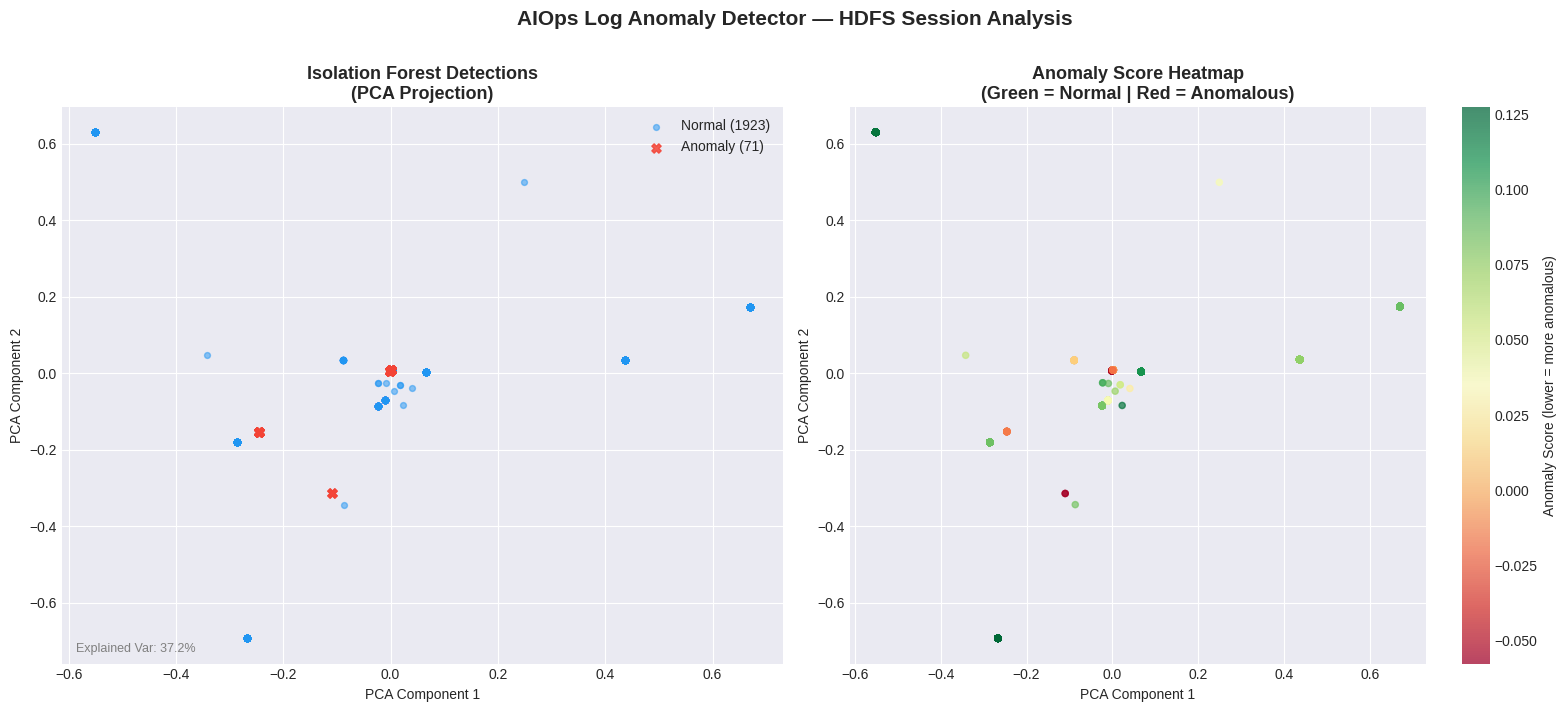

✅ Visualization saved: phase5_pca_visualization.png


In [ ]:
# ── PCA Visualization: 2D Scatter of Normal vs Anomaly Sessions ───────────────
# Flatten 500-dimensional TF-IDF space → 2D for human inspection

pca = PCA(n_components=2, random_state=42)
X_dense = X_tfidf.toarray()
X_2d    = pca.fit_transform(X_dense)

df_sessions['pca_x'] = X_2d[:, 0]
df_sessions['pca_y'] = X_2d[:, 1]

explained = pca.explained_variance_ratio_.sum()
print(f"📐 PCA explained variance (2 components): {explained:.1%}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: Isolation Forest Predictions
ax = axes[0]
normal_mask  = ~df_sessions['is_anomaly']
anomaly_mask =  df_sessions['is_anomaly']

ax.scatter(
    df_sessions.loc[normal_mask, 'pca_x'],
    df_sessions.loc[normal_mask, 'pca_y'],
    c='#2196F3', alpha=0.5, s=18, label=f'Normal ({normal_mask.sum()})', zorder=2
)
ax.scatter(
    df_sessions.loc[anomaly_mask, 'pca_x'],
    df_sessions.loc[anomaly_mask, 'pca_y'],
    c='#F44336', alpha=0.85, s=45, marker='X', label=f'Anomaly ({anomaly_mask.sum()})', zorder=3
)
ax.set_title('Isolation Forest Detections\n(PCA Projection)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PCA Component 1')
ax.set_ylabel(f'PCA Component 2')
ax.legend(framealpha=0.9)
ax.text(0.02, 0.02, f'Explained Var: {explained:.1%}', transform=ax.transAxes,
        fontsize=9, color='gray')

# RIGHT: Anomaly Score Heatmap (colour = anomaly_score)
ax2 = axes[1]
sc = ax2.scatter(
    df_sessions['pca_x'], df_sessions['pca_y'],
    c=df_sessions['anomaly_score'],
    cmap='RdYlGn', alpha=0.7, s=20, vmin=df_sessions['anomaly_score'].min(),
    vmax=df_sessions['anomaly_score'].max()
)
plt.colorbar(sc, ax=ax2, label='Anomaly Score (lower = more anomalous)')
ax2.set_title('Anomaly Score Heatmap\n(Green = Normal | Red = Anomalous)', fontsize=13, fontweight='bold')
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')

plt.suptitle('AIOps Log Anomaly Detector — HDFS Session Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('phase5_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved: phase5_pca_visualization.png")

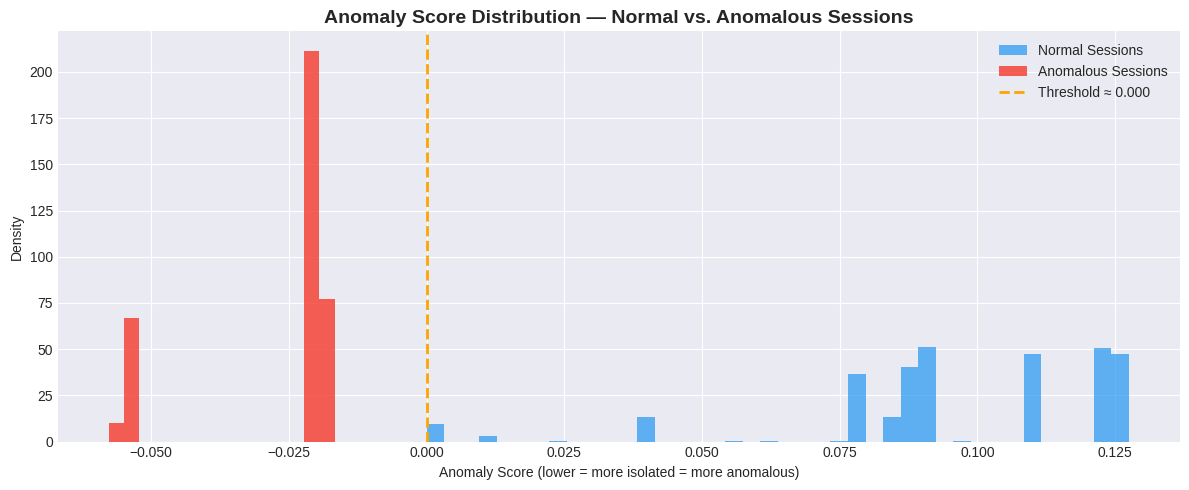

✅ Distribution saved: phase5_score_distribution.png


In [ ]:
# ── Anomaly Score Distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    df_sessions.loc[normal_mask, 'anomaly_score'],
    bins=40, color='#2196F3', alpha=0.7, label='Normal Sessions', density=True
)
ax.hist(
    df_sessions.loc[anomaly_mask, 'anomaly_score'],
    bins=15, color='#F44336', alpha=0.85, label='Anomalous Sessions', density=True
)

threshold = df_sessions['anomaly_score'].quantile(0.05)
ax.axvline(threshold, color='orange', linestyle='--', linewidth=2, label=f'Threshold ≈ {threshold:.3f}')
ax.set_title('Anomaly Score Distribution — Normal vs. Anomalous Sessions', fontsize=14, fontweight='bold')
ax.set_xlabel('Anomaly Score (lower = more isolated = more anomalous)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('phase5_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution saved: phase5_score_distribution.png")

In [ ]:
# ── False Positive Analysis ───────────────────────────────────────────────────
# Inspect the false positives: sessions flagged as anomaly but containing NO errors
fp_sessions = df_sessions[
    (df_sessions['is_anomaly'] == True) & (df_sessions['has_error'] == 0)
].sort_values('anomaly_score').head(5)

print("🔎 False Positive Analysis — Top 5 Suspicious 'Normal' Sessions:")
for _, row in fp_sessions.iterrows():
    print(f"\n  Block ID: {row['Block_ID']}")
    print(f"  Anomaly Score: {row['anomaly_score']:.4f} | Log Count: {row['log_count']}")
    print(f"  Content (truncated): {row['full_content'][:250]}...")
    print("  " + "─"*80)

print("""
💡 Tuning Recommendation:
   If false positives are high, try:
   1. Increase min_df in TfidfVectorizer (e.g., min_df=3) to ignore very rare terms
   2. Reduce max_features to focus on most discriminative tokens
   3. Increase contamination threshold (e.g., 0.03) to be more conservative
   4. Add domain stopwords (e.g., 'received', 'serving', 'packet') to TF-IDF stop_words
""")

🔎 False Positive Analysis — Top 5 Suspicious 'Normal' Sessions:

  Block ID: blk_6400082566804273401
  Anomaly Score: -0.0577 | Log Count: 2
  Content (truncated): BLOCK* NameSystem.allocateBlock: /user/root/rand5/_temporary/_task_200811101024_0011_m_001730_0/part-01730. blk_6400082566804273401 Receiving block blk_6400082566804273401 src: /10.251.38.214:42160 dest: /10.251.38.214:50010...
  ────────────────────────────────────────────────────────────────────────────────

  Block ID: blk_8596624696139957935
  Anomaly Score: -0.0577 | Log Count: 2
  Content (truncated): Receiving block blk_8596624696139957935 src: /10.251.214.175:41468 dest: /10.251.214.175:50010 BLOCK* NameSystem.allocateBlock: /user/root/rand6/_temporary/_task_200811101024_0013_m_000153_0/part-00153. blk_8596624696139957935...
  ────────────────────────────────────────────────────────────────────────────────

  Block ID: blk_-207775976836691685
  Anomaly Score: -0.0544 | Log Count: 1
  Content (truncated): BLOCK* NameS

In [ ]:
# ── Export Anomaly Report ─────────────────────────────────────────────────────
output_report = df_sessions[[
    'Block_ID', 'anomaly_score', 'is_anomaly', 'prediction',
    'has_error', 'error_count', 'has_warn', 'log_count',
    'unique_components', 'full_content'
]].sort_values('anomaly_score')

output_report.to_csv('anomaly_report.csv', index=False)
print(f"✅ Anomaly report exported: anomaly_report.csv ({len(output_report):,} rows)")

# Summary metrics
print("\n" + "═"*55)
print("       AIOPS LOG ANOMALY DETECTOR — FINAL SUMMARY")
print("═"*55)
print(f"  Total log lines processed :  {len(df_raw):,}")
print(f"  Unique Block_ID sessions  :  {len(df_sessions):,}")
print(f"  Anomalies detected        :  {df_sessions['is_anomaly'].sum():,}")
print(f"  Anomaly rate              :  {df_sessions['is_anomaly'].mean():.1%}")
print(f"  TF-IDF features           :  {X_tfidf.shape[1]:,}")
print(f"  PCA explained variance    :  {explained:.1%}")
if len(error_sessions) > 0:
    print(f"  ERROR recall              :  {recall:.1%}")
    print(f"  False positive rate       :  {fp_rate:.1%}")
print("═"*55)

✅ Anomaly report exported: anomaly_report.csv (1,994 rows)

═══════════════════════════════════════════════════════
       AIOPS LOG ANOMALY DETECTOR — FINAL SUMMARY
═══════════════════════════════════════════════════════
  Total log lines processed :  2,000
  Unique Block_ID sessions  :  1,994
  Anomalies detected        :  71
  Anomaly rate              :  3.6%
  TF-IDF features           :  121
  PCA explained variance    :  37.2%
═══════════════════════════════════════════════════════
